Cell 1: Imports

In [1]:
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

fake = Faker('en_AU')
random.seed(42)
np.random.seed(42)

PROCESSED_PATH = '../data/processed/'
print('Libraries loaded.')

Libraries loaded.


Cell 2 — Load the real sites table:

In [2]:
sites = pd.read_csv('../data/processed/sites.csv')

# Keep only the columns we need and take top 20 sites by area
sites = sites[['site_id', 'operator_name', 'COMMODITY', 'REGION', 'total_area_ha']].copy()
sites = sites.sort_values('total_area_ha', ascending=False).head(20).reset_index(drop=True)
sites['site_id'] = range(1, len(sites) + 1)

print(f'Sites loaded: {len(sites)}')
sites[['site_id', 'operator_name', 'COMMODITY', 'REGION']].head(10)

Sites loaded: 20


,site_id,operator_name,COMMODITY,REGION
0,1,FMG PILBARA PTY LTD,Iron Ore,Pilbara
1,2,BIG BELL GOLD OPERATIONS PTY LTD,Gold,Goldfields
2,3,CHICHESTER METALS PTY LTD,Iron Ore,Pilbara
3,4,AGNEW GOLD MINING COMPANY PTY LIMITED,Gold,Goldfields
4,5,BHP NICKEL WEST PTY LTD,Nickel,Goldfields
5,6,MURRIN MURRIN OPERATIONS PTY LTD,Nickel,Goldfields
6,7,ST IVES GOLD MINING COMPANY PTY LIMITED,Gold,Goldfields
7,8,CENTRAL NORSEMAN GOLD CORPORATION PTY LTD,Gold,Goldfields
8,9,NORTHERN STAR RESOURCES LTD,Other,Other WA
9,10,PADDINGTON GOLD PTY LIMITED,Gold,Goldfields


Cell 3 — Generate workers:

In [3]:
roles = ['Underground Miner', 'Surface Operator', 'Drill & Blast Technician',
         'Haul Truck Operator', 'Maintenance Technician', 'Electrical Engineer',
         'Safety Officer', 'Shift Supervisor', 'Processing Plant Operator', 'Geologist']

departments = ['Mining Operations', 'Maintenance', 'Processing', 'Safety & Environment',
               'Drill & Blast', 'Logistics', 'Engineering']

employment_types = ['Full-time', 'Contractor', 'FIFO']
employment_weights = [0.5, 0.3, 0.2]

workers = []
worker_id = 1

for _, site in sites.iterrows():
    n_workers = random.randint(80, 300)
    for _ in range(n_workers):
        workers.append({
            'worker_id': worker_id,
            'site_id': int(site['site_id']),
            'first_name': fake.first_name(),
            'last_name': fake.last_name(),
            'role': random.choice(roles),
            'department': random.choice(departments),
            'employment_type': random.choices(employment_types, employment_weights)[0],
            'start_date': fake.date_between(start_date='-10y', end_date='-6m')
        })
        worker_id += 1

workers_df = pd.DataFrame(workers)
print(f'Workers generated: {len(workers_df):,}')
print(workers_df['employment_type'].value_counts())
workers_df.head(5)

Workers generated: 3,616
employment_type
Full-time     1811
Contractor    1117
FIFO           688
Name: count, dtype: int64


,worker_id,site_id,first_name,last_name,role,department,employment_type,start_date
0,1,1,Theodore,Reid,Surface Operator,Mining Operations,Contractor,2023-10-14
1,2,1,Larry,Dixon,Haul Truck Operator,Maintenance,Full-time,2016-09-06
2,3,1,Susan,Pena,Surface Operator,Logistics,Contractor,2020-03-02
3,4,1,Richard,Perez,Processing Plant Operator,Mining Operations,Contractor,2018-02-01
4,5,1,Kyle,Clayton,Underground Miner,Mining Operations,Full-time,2024-03-30


Cell 4 — Generate incidents:

In [4]:
# Calibrated to WA DMIRS safety statistics
# TRIFR range 3-6 per million hours worked
incident_types  = ['LTI', 'MTI', 'FAI', 'Fatality']
type_weights    = [0.20,  0.45,  0.30,  0.05]

hazard_categories = [
    'Ground fall', 'Mobile equipment', 'Fall from height',
    'Explosives', 'Electrical', 'Hazardous substances', 'Manual handling'
]
hazard_weights = [0.25, 0.30, 0.15, 0.10, 0.08, 0.07, 0.05]

body_parts = ['Back', 'Hand', 'Head', 'Foot', 'Eye', 'Shoulder', 'Knee', 'Multiple']
shifts     = ['Day', 'Afternoon', 'Night']

incidents = []
incident_id = 1

for _, site in sites.iterrows():
    site_workers = workers_df[workers_df['site_id'] == site['site_id']]
    n_incidents = random.randint(15, 60)

    for _ in range(n_incidents):
        inc_type = random.choices(incident_types, type_weights)[0]
        days_lost = 0
        if inc_type == 'LTI':
            days_lost = random.randint(1, 90)
        elif inc_type == 'Fatality':
            days_lost = 0

        worker = site_workers.sample(1).iloc[0] if len(site_workers) > 0 else None

        incidents.append({
            'incident_id':       incident_id,
            'site_id':           int(site['site_id']),
            'worker_id':         int(worker['worker_id']) if worker is not None else None,
            'incident_date':     fake.date_between(start_date='-3y', end_date='today'),
            'incident_type':     inc_type,
            'hazard_category':   random.choices(hazard_categories, hazard_weights)[0],
            'severity':          random.choice(['Low', 'Medium', 'High', 'Critical']),
            'shift':             random.choice(shifts),
            'body_part_injured': random.choice(body_parts),
            'days_lost':         days_lost,
            'description':       fake.sentence(nb_words=12),
            'corrective_action': fake.sentence(nb_words=10)
        })
        incident_id += 1

incidents_df = pd.DataFrame(incidents)
print(f'Incidents generated: {len(incidents_df):,}')
print(incidents_df['incident_type'].value_counts())
incidents_df.head(5)

Incidents generated: 567
incident_type
MTI         258
FAI         151
LTI         128
Fatality     30
Name: count, dtype: int64


,incident_id,site_id,worker_id,incident_date,incident_type,hazard_category,severity,shift,body_part_injured,days_lost,description,corrective_action
0,1,1,25,2026-01-12,LTI,Mobile equipment,High,Night,Shoulder,25,Pariatur iusto aliquid expedita ipsam repudian...,Quibusdam facilis animi ad ipsa magnam dolor s...
1,2,1,133,2025-11-12,FAI,Mobile equipment,Low,Afternoon,Hand,0,Suscipit vitae eaque eveniet deleniti quidem e...,Corrupti nisi dolorum est cum soluta tempora q...
2,3,1,106,2023-06-15,MTI,Mobile equipment,Low,Day,Eye,0,Nisi voluptatum neque expedita consectetur tem...,Iusto iusto iure perferendis natus porro eum u...
3,4,1,199,2023-06-17,FAI,Ground fall,Low,Night,Back,0,Nobis exercitationem fugiat unde laborum sit n...,Cum dolorum iste eligendi blanditiis quibusdam...
4,5,1,240,2024-12-25,FAI,Fall from height,Critical,Afternoon,Hand,0,Autem ullam voluptatem odit est tenetur eligen...,Magnam itaque vel itaque architecto sequi prov...


Cell 5 — Generate near-miss reports:

In [5]:
near_miss = []
nm_id = 1

for _, site in sites.iterrows():
    n_nm = random.randint(30, 120)  # near-misses > incidents (iceberg model)
    for _ in range(n_nm):
        near_miss.append({
            'near_miss_id':            nm_id,
            'site_id':                 int(site['site_id']),
            'report_date':             fake.date_between(start_date='-3y', end_date='today'),
            'hazard_category':         random.choices(hazard_categories, hazard_weights)[0],
            'shift':                   random.choice(shifts),
            'location_on_site':        random.choice(['Open pit', 'Underground', 'Processing plant',
                                                       'Workshop', 'Haul road', 'Camp']),
            'potential_severity':      random.choice(['Low', 'Medium', 'High']),
            'corrective_action_taken': random.choice([True, False]),
            'description':             fake.sentence(nb_words=14)
        })
        nm_id += 1

near_miss_df = pd.DataFrame(near_miss)
print(f'Near-miss reports generated: {len(near_miss_df):,}')
print(near_miss_df['hazard_category'].value_counts())
near_miss_df.head(5)

Near-miss reports generated: 1,518
hazard_category
Mobile equipment        449
Ground fall             374
Fall from height        201
Explosives              154
Electrical              134
Hazardous substances    111
Manual handling          95
Name: count, dtype: int64


,near_miss_id,site_id,report_date,hazard_category,shift,location_on_site,potential_severity,corrective_action_taken,description
0,1,1,2025-10-13,Hazardous substances,Night,Underground,Medium,True,Fugiat laboriosam laboriosam nisi sit iste sun...
1,2,1,2023-12-02,Mobile equipment,Day,Processing plant,High,True,Veritatis quidem rem quae aliquam dignissimos ...
2,3,1,2024-01-10,Mobile equipment,Night,Camp,High,True,Id nemo velit ipsum perferendis distinctio id ...
3,4,1,2025-02-18,Manual handling,Day,Workshop,High,True,Perferendis fugit iusto odit minima voluptatum...
4,5,1,2023-11-24,Ground fall,Night,Underground,High,True,Nulla animi velit veniam exercitationem volupt...


Cell 6 — Generate inspections:

In [6]:
inspections = []
insp_id = 1

for _, site in sites.iterrows():
    n_insp = random.randint(8, 24)  # roughly monthly to bi-monthly
    for _ in range(n_insp):
        score = round(random.gauss(72, 12))  # normally distributed around 72%
        score = max(30, min(100, score))     # clamp between 30 and 100
        passed = score >= 60

        inspections.append({
            'inspection_id':   insp_id,
            'site_id':         int(site['site_id']),
            'inspection_date': fake.date_between(start_date='-3y', end_date='today'),
            'inspector':       fake.name(),
            'inspection_type': random.choice(['Routine', 'Unannounced', 'Follow-up', 'Regulatory']),
            'findings_count':  random.randint(0, 15),
            'score':           score,
            'passed':          passed
        })
        insp_id += 1

inspections_df = pd.DataFrame(inspections)
print(f'Inspections generated: {len(inspections_df):,}')
print(f'Pass rate: {inspections_df["passed"].mean()*100:.1f}%')
inspections_df.head(5)

Inspections generated: 296
Pass rate: 88.5%


,inspection_id,site_id,inspection_date,inspector,inspection_type,findings_count,score,passed
0,1,1,2024-10-25,Renee Fernandez,Follow-up,5,51,False
1,2,1,2024-03-21,Guy Hogan,Regulatory,14,96,True
2,3,1,2025-01-14,Tracy Boone,Regulatory,1,71,True
3,4,1,2025-10-13,Daniel Arias,Routine,15,95,True
4,5,1,2025-07-19,Joshua Ho,Routine,13,83,True


Cell 7 — Generate compliance actions:

In [7]:
statuses        = ['Open', 'Closed', 'Overdue']
status_weights  = [0.35, 0.50, 0.15]

compliance = []
action_id = 1

for _, insp in inspections_df.iterrows():
    n_actions = insp['findings_count']
    for _ in range(n_actions):
        due_date = fake.date_between(start_date='-2y', end_date='+6m')
        status   = random.choices(statuses, status_weights)[0]

        compliance.append({
            'action_id':          action_id,
            'inspection_id':      int(insp['inspection_id']),
            'site_id':            int(insp['site_id']),
            'action_description': fake.sentence(nb_words=10),
            'due_date':           due_date,
            'status':             status,
            'priority':           random.choice(['Low', 'Medium', 'High'])
        })
        action_id += 1

compliance_df = pd.DataFrame(compliance)
print(f'Compliance actions generated: {len(compliance_df):,}')
print(compliance_df['status'].value_counts())
compliance_df.head(5)

Compliance actions generated: 2,175
status
Closed     1096
Open        763
Overdue     316
Name: count, dtype: int64


,action_id,inspection_id,site_id,action_description,due_date,status,priority
0,1,1,1,Harum nam numquam numquam facilis ratione.,2026-05-04,Open,Medium
1,2,1,1,Assumenda rerum aperiam beatae mollitia conseq...,2024-08-05,Open,Medium
2,3,1,1,Modi expedita magnam sed consequatur occaecati...,2024-06-27,Closed,Low
3,4,1,1,Adipisci eius quam temporibus alias nobis exce...,2026-05-19,Open,Low
4,5,1,1,Ab quisquam minus deleniti aperiam distinctio ...,2024-12-12,Open,High


Cell 8 — Export all tables:

In [8]:
os.makedirs(PROCESSED_PATH, exist_ok=True)

sites.to_csv(f'{PROCESSED_PATH}sites.csv', index=False)
workers_df.to_csv(f'{PROCESSED_PATH}workers.csv', index=False)
incidents_df.to_csv(f'{PROCESSED_PATH}incidents.csv', index=False)
near_miss_df.to_csv(f'{PROCESSED_PATH}near_miss.csv', index=False)
inspections_df.to_csv(f'{PROCESSED_PATH}inspections.csv', index=False)
compliance_df.to_csv(f'{PROCESSED_PATH}compliance_actions.csv', index=False)

print('All tables exported to data/processed/')
print(f'  sites:              {len(sites):,} rows')
print(f'  workers:            {len(workers_df):,} rows')
print(f'  incidents:          {len(incidents_df):,} rows')
print(f'  near_miss:          {len(near_miss_df):,} rows')
print(f'  inspections:        {len(inspections_df):,} rows')
print(f'  compliance_actions: {len(compliance_df):,} rows')

All tables exported to data/processed/
  sites:              20 rows
  workers:            3,616 rows
  incidents:          567 rows
  near_miss:          1,518 rows
  inspections:        296 rows
  compliance_actions: 2,175 rows


Cell 9 — Quick summary chart:

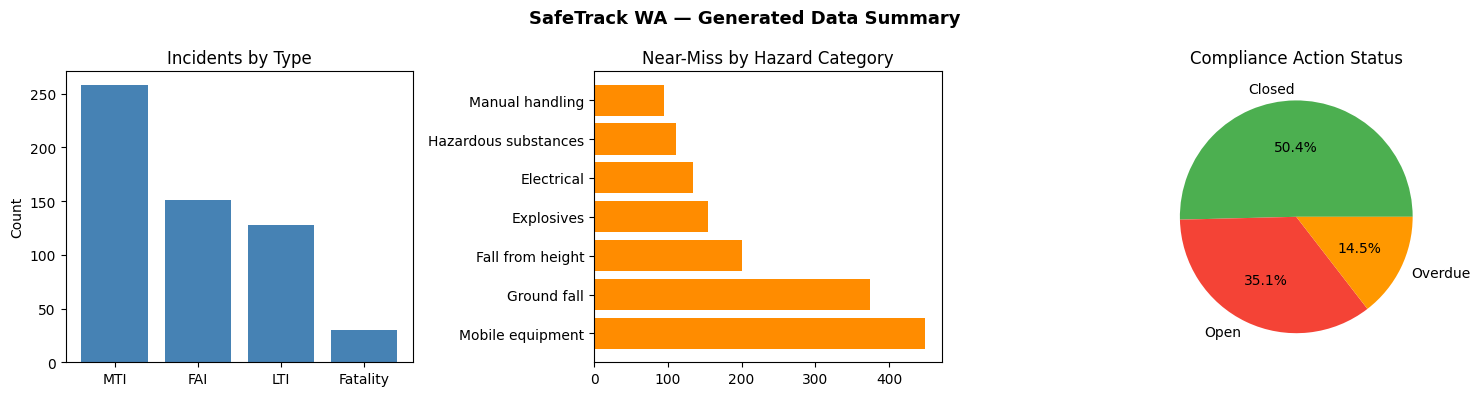

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Incidents by type
inc_counts = incidents_df['incident_type'].value_counts()
axes[0].bar(inc_counts.index, inc_counts.values, color='steelblue')
axes[0].set_title('Incidents by Type')
axes[0].set_ylabel('Count')

# Near-miss by hazard
nm_counts = near_miss_df['hazard_category'].value_counts()
axes[1].barh(nm_counts.index, nm_counts.values, color='darkorange')
axes[1].set_title('Near-Miss by Hazard Category')

# Compliance status
comp_counts = compliance_df['status'].value_counts()
colors = ['#4CAF50', '#F44336', '#FF9800']
axes[2].pie(comp_counts.values, labels=comp_counts.index,
            autopct='%1.1f%%', colors=colors)
axes[2].set_title('Compliance Action Status')

plt.suptitle('SafeTrack WA — Generated Data Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()